## Import

In [1]:
import os 
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import cv2 
import random
import pandas as pd
import numpy as np 
from PIL import Image

import torch 
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time
from sklearn.metrics import (classification_report,f1_score,confusion_matrix,
roc_auc_score, average_precision_score, precision_recall_curve)


## Dataset Exploring

In [2]:
class DatasetExplorer:
    def __init__(self, data_path = '/kaggle/input/car-damage-detection'):
        ''' One class make everything in the data'''
        self.path = Path(data_path)
        self.img_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
        self.stats = {}
    def exploring_data_structure(self):
        ''' get the structure of the data'''
        for root, dirs, files in os.walk(self.path):
            level = root.replace(str(self.path),'').count(os.sep)
            indent = ' '* 2* level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' '* 2* (level+1)
            for file in files[:5]:
                print(f'{subindent}{file}')
            if len(files) >5:
                print(f'{subindent}... and {len(files) - 5} more files')
    def count_image(self):
        '''Count total images and their distribution'''
        img_counts = defaultdict(int)
        total_images = 0
        for root, dirs, files in os.walk(self.path):
            for file in files:
                if Path(file).suffix in self.img_extensions:
                    total_images +=1
                    folder = os.path.basename(root)
                    img_counts[folder] +=1
        print(f"Total images found: {total_images}")
        print("\nImages by folder:")
        for folder, count in sorted(img_counts.items()):
            print(f"  {folder}: {count}")
        self.stats['total_images'] = total_images
        self.stats['images_by_folder'] = img_counts
        return img_counts

    def analyze_image_dimensions(self, sample_size= 50):
        '''Analyze dimensions of images (height, width, channels)'''
        dimensions = []
        channels_list = []
        count = 0
        for root, dirs, files in os.walk(self.path):
            for file in files:
                if Path(file).suffix in self.img_extensions:
                    img_path = os.path.join(root, file)
                    try:
                        img = cv2.imread(img_path)
                        height, width = img.shape[:2]
                        channel = img.shape[2] if len(img.shape) == 3 else 1
                        dimensions.append({'height': height, 'width': width})
                        channels_list.append(channel)
                        count +=1
                        if count>=sample_size:
                            break
                    except Exception as e :
                        print(f"Error reading {img_path}: {e}")
            if count>=sample_size:
                break
        df_dims = pd.DataFrame(dimensions)
        print(f"\nHeight statistics:")
        print(df_dims['height'].describe())
        print(f"\nWidth statistics:")
        print(df_dims['width'].describe())
        print(f"\nImage channels: {set(channels_list)}")
        self.stats['dimensions_sample'] = df_dims
        self.stats['channels'] = set(channels_list)
        
    def sample_img_visualization(self,num_samples=6):
        """Visualize sample images from the dataset"""
        image_paths = []
        for root, dirs, files in os.walk(self.path):
            for file in files:
                if Path(file).suffix in self.img_extensions:
                    image_paths.append(os.path.join(root, file))
        sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        for idx, img_path in enumerate(sample_paths):
            try:
                img = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                print(img_rgb.shape)
                axes[idx].imshow(img_rgb)
                axes[idx].set_title(Path(img_path).parent.name + "/" + Path(img_path).name, 
                                   fontsize=10)
                axes[idx].axis('off')
            except Exception as e:
                axes[idx].text(0.5, 0.5, f'Error: {e}', ha='center')
                axes[idx].axis('off')
        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """Print overall summary"""
        print("\n" + "=" * 60)
        print("SUMMARY")
        print("=" * 60)
        print(f"Total images: {self.stats.get('total_images', 'N/A')}")
        print(f"Images by folder: {self.stats.get('images_by_folder', {})}")
        print(f"Image channels: {self.stats.get('channels', 'N/A')}")
        
        if 'dimensions_sample' in self.stats:
            df = self.stats['dimensions_sample']
            print(f"\nImage size range:")
            print(f"  Height: {df['height'].min()} - {df['height'].max()} px")
            print(f"  Width: {df['width'].min()} - {df['width'].max()} px")

                

                
        

In [3]:
DatasetExplorer= DatasetExplorer()

In [4]:
DatasetExplorer.exploring_data_structure()

car-damage-detection/
  CarDD_release/
    CarDD_COCO/
      val2017/
        001940.jpg
        000748.jpg
        000857.jpg
        000853.jpg
        003479.jpg
        ... and 805 more files
      annotations/
        instances_test2017.json
        image_info.xlsx
        instances_val2017.json
        instances_train2017.json
      test2017/
        000875.jpg
        001071.jpg
        001506.jpg
        002056.jpg
        003831.jpg
        ... and 369 more files
      train2017/
        000304.jpg
        001229.jpg
        001989.jpg
        000780.jpg
        003113.jpg
        ... and 2811 more files
    CarDD_SOD/
      CarDD-TR/
        train_pair.lst
        CarDD-TR-Edge/
          003065.png
          003741.png
          001183.png
          002594.png
          001703.png
          ... and 2811 more files
        CarDD-TR-Mask/
          003065.png
          003741.png
          001183.png
          002594.png
          001703.png
          ... and 2811 more files
 

In [5]:
DatasetExplorer.analyze_image_dimensions()


Height statistics:
count      50.000000
mean      702.600000
std        96.571851
min       563.000000
25%       667.000000
50%       667.000000
75%       668.000000
max      1000.000000
Name: height, dtype: float64

Width statistics:
count      50.000000
mean      974.940000
std        86.479539
min       662.000000
25%      1000.000000
50%      1000.000000
75%      1000.000000
max      1000.000000
Name: width, dtype: float64

Image channels: {3}


(667, 1000, 3)
(750, 1000, 3)
(820, 1000, 3)
(667, 1000, 3)
(657, 1000, 3)
(667, 1000, 3)


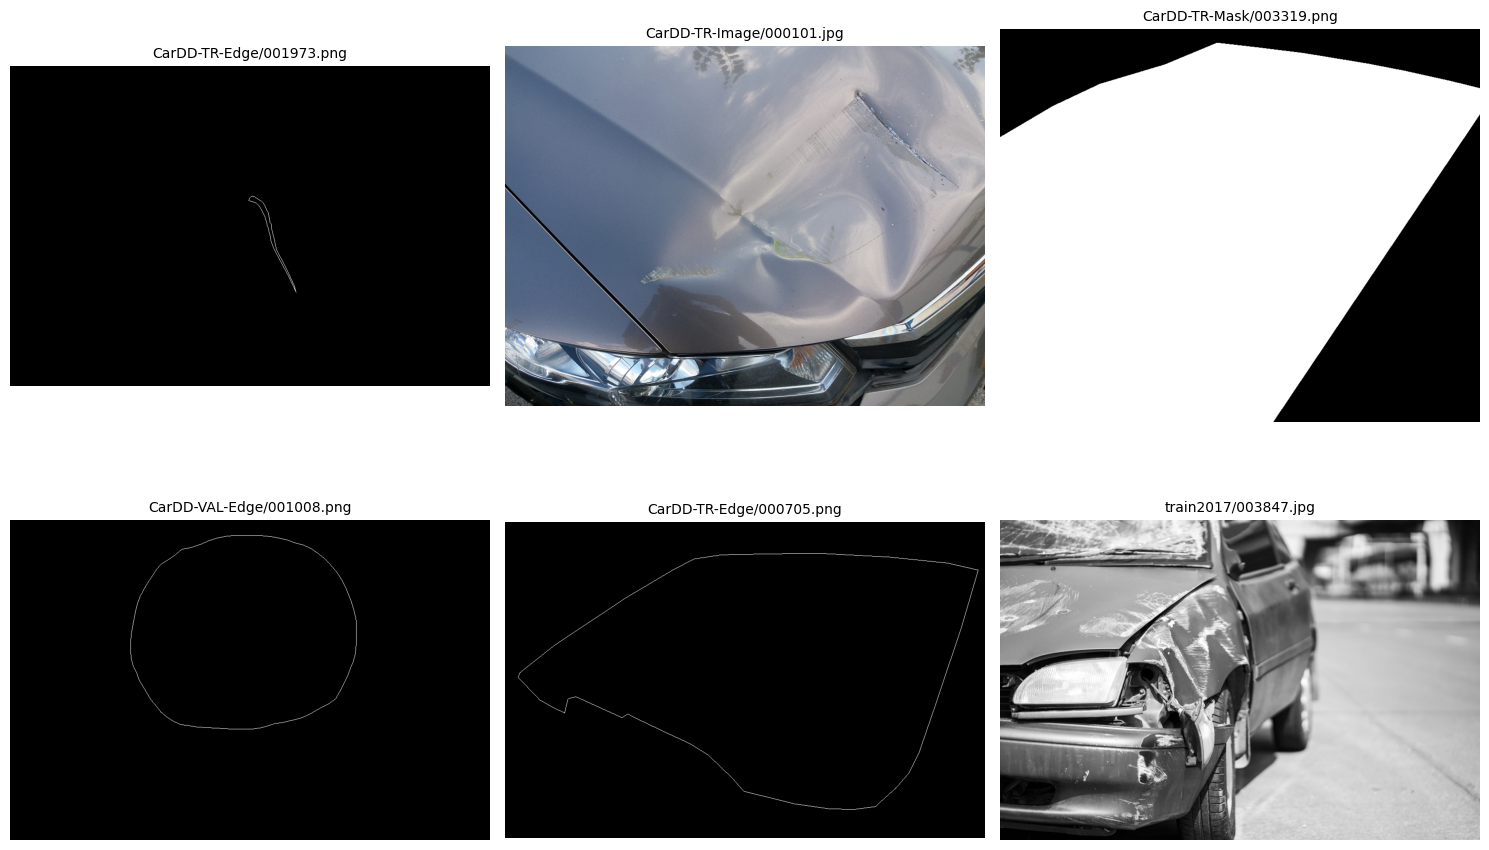

In [6]:
DatasetExplorer.sample_img_visualization()

In [7]:
DatasetExplorer.print_summary()


SUMMARY
Total images: N/A
Images by folder: {}
Image channels: {3}

Image size range:
  Height: 563 - 1000 px
  Width: 662 - 1000 px


In [8]:
with open('/kaggle/input/car-damage-detection/CarDD_release/CarDD_COCO/annotations/instances_train2017.json') as f:
    data= json.load(f)
print((data['categories']))

[{'id': 1, 'name': 'dent'}, {'id': 2, 'name': 'scratch'}, {'id': 3, 'name': 'crack'}, {'id': 4, 'name': 'glass shatter'}, {'id': 5, 'name': 'lamp broken'}, {'id': 6, 'name': 'tire flat'}]


## Constants

In [9]:
BASE = '/kaggle/input/car-damage-detection/CarDD_release/CarDD_COCO'
SPLITS = {
    'train': f'{BASE}/annotations/instances_train2017.json',
    'val':   f'{BASE}/annotations/instances_val2017.json',
    'test':  f'{BASE}/annotations/instances_test2017.json',
}

IMG_DIRS = {
    'train': f'{BASE}/train2017',
    'val':   f'{BASE}/val2017',
    'test':  f'{BASE}/test2017',
}

In [10]:
DEVICE= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE  

device(type='cuda')

In [11]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
SIZE = (224, 224)
threshold = 0.5
NUM_EPOCHS = 60

In [12]:
# parse function 
def parse_coco_2_df(json_file, split_name):
    with open(json_file) as f :
        data = json.load(f)

    cat_map = {c['id']: c['name'] for c in data['categories']}
    img_map = {img['id']:img['file_name'] for img in data['images']}
    img_labels = defaultdict(set)
    for ann in data['annotations']:
        img_id = ann['image_id']
        cat_name = cat_map[ann['category_id']]
        img_labels[img_id].add(cat_name)
    rows = []
    for img_id, label in img_labels.items():
        rows.append({
            "image_id":img_id,
            "file_name":img_map[img_id],
            "split_name":split_name,
            "labels": sorted(label),
            "num_labels": len(label),
            # one-hot columns
            'dent':         int('dent'         in label),
            'scratch':      int('scratch'      in label),
            'crack':        int('crack'        in label),
            'glass_shatter':int('glass shatter' in label),
            'lamp_broken':  int('lamp broken'  in label),
            'tire_flat':    int('tire flat'    in label),
            
        })
    return pd.DataFrame(rows)


In [13]:
dfs = [parse_coco_2_df(path, split) for split, path in SPLITS.items() ]
df = pd.concat(dfs, ignore_index=False)

In [14]:
df

,image_id,file_name,split_name,labels,num_labels,dent,scratch,crack,glass_shatter,lamp_broken,tire_flat
0,1,000001.jpg,train,"[scratch, tire flat]",2,0,1,0,0,0,1
1,2,000002.jpg,train,[tire flat],1,0,0,0,0,0,1
2,3,000003.jpg,train,[tire flat],1,0,0,0,0,0,1
3,4,000004.jpg,train,[tire flat],1,0,0,0,0,0,1
4,5,000005.jpg,train,[tire flat],1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
369,3959,003959.jpg,test,[glass shatter],1,0,0,0,1,0,0
370,3977,003977.jpg,test,[glass shatter],1,0,0,0,1,0,0
371,3992,003992.jpg,test,[dent],1,1,0,0,0,0,0
372,3993,003993.jpg,test,[glass shatter],1,0,0,0,1,0,0


In [15]:
print(df.shape)
print(df['split_name'].value_counts())
print('\nLabel distribution:')
print(df[['dent','scratch','crack','glass_shatter','lamp_broken','tire_flat']].sum())
print('\nMulti-label frequency:')
print(df['num_labels'].value_counts().sort_index())


(4000, 11)
split_name
train    2816
val       810
test      374
Name: count, dtype: int64

Label distribution:
dent             1751
scratch          2121
crack             604
glass_shatter     674
lamp_broken       693
tire_flat         309
dtype: int64

Multi-label frequency:
num_labels
1    2470
2    1030
3     387
4     104
5       9
Name: count, dtype: int64


## EDA

In [16]:
CLASSES =  ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']
COLORS  = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']


/tmp/ipykernel_24/4189906174.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(labels= CLASSES, rotation=30 )


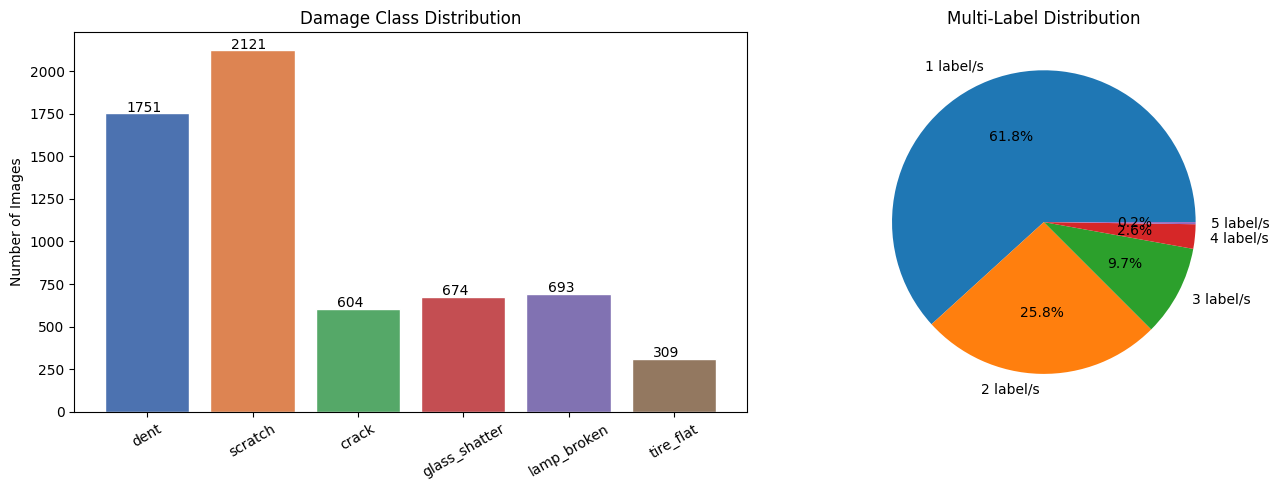

In [17]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
# class distribution
counts = df[CLASSES].sum().values
bars = axes[0].bar(CLASSES, counts, color=COLORS, edgecolor= 'white' )
axes[0].set_title('Damage Class Distribution')
axes[0].set_ylabel('Number of Images')
axes[0].set_xticklabels(labels= CLASSES, rotation=30 )
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x()+ bar.get_width()/4, bar.get_height()+10, str(count))
# multi label distribution 
labels_counts= df['num_labels'].value_counts().sort_index()
axes[1].pie(labels_counts.values,labels=[f'{i} label/s' for i in labels_counts.index], autopct='%1.1f%%' )
axes[1].set_title('Multi-Label Distribution')


plt.tight_layout()
plt.show()

In [18]:
samples = []
for cls in CLASSES:
    row = df[(df[cls]==1)& (df['num_labels']==1)].iloc[0]
    samples.append(row)
for i,row in df[df['num_labels']>=3].iloc[:2].iterrows():
    samples.append(row)
samples = pd.DataFrame(samples)
samples

,image_id,file_name,split_name,labels,num_labels,dent,scratch,crack,glass_shatter,lamp_broken,tire_flat
19,28,000028.jpg,train,[dent],1,1,0,0,0,0,0
12,18,000018.jpg,train,[scratch],1,0,1,0,0,0,0
23,32,000032.jpg,train,[crack],1,0,0,1,0,0,0
27,41,000041.jpg,train,[glass shatter],1,0,0,0,1,0,0
55,77,000077.jpg,train,[lamp broken],1,0,0,0,0,1,0
1,2,000002.jpg,train,[tire flat],1,0,0,0,0,0,1
8,9,000009.jpg,train,"[dent, scratch, tire flat]",3,1,1,0,0,0,1
11,14,000014.jpg,train,"[dent, scratch, tire flat]",3,1,1,0,0,0,1


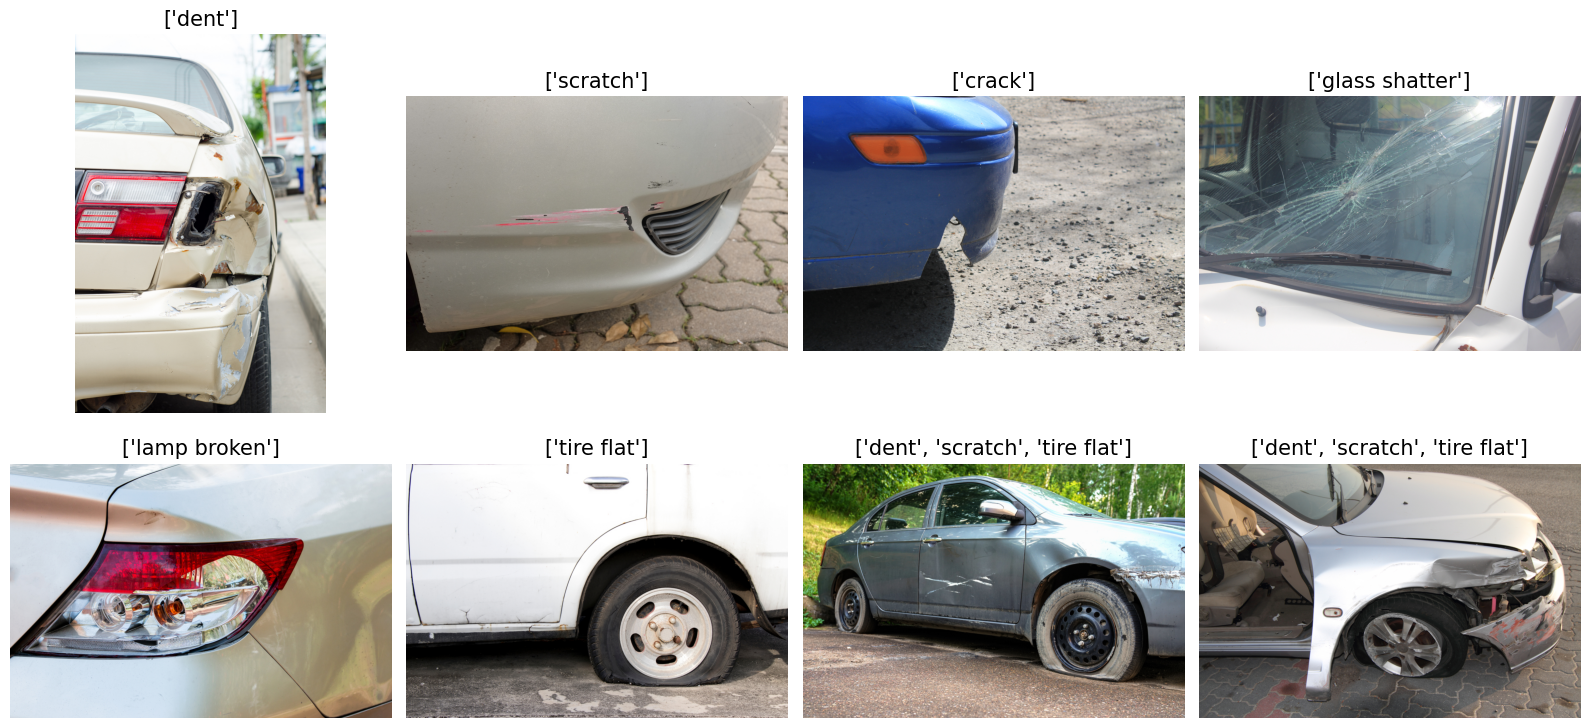

In [19]:
fig, axes = plt.subplots(2,4,figsize=(16,8))
axes=axes.flatten()
for i, (ax,(_, row)) in enumerate(zip(axes,samples.iterrows())):
    img_path = os.path.join(BASE, f'{row["split_name"]}2017', f'{row["file_name"]}')
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(row['labels'], fontsize=15)


plt.tight_layout()
plt.show()

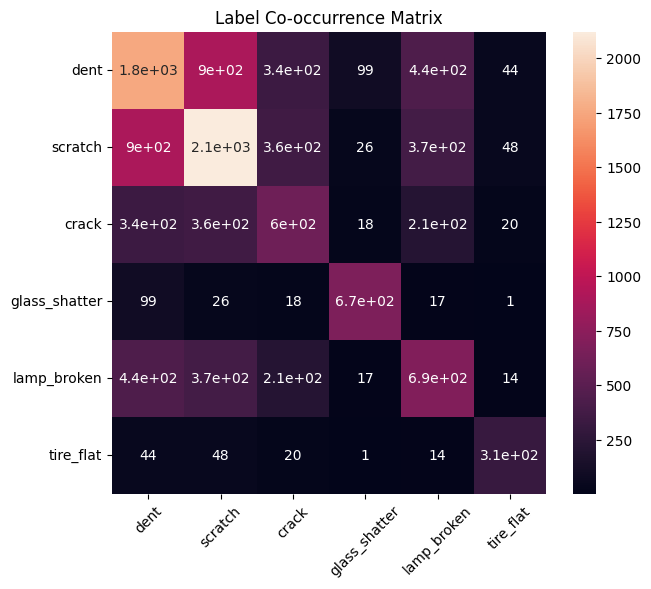

In [20]:
# Co-occurrence heatmap
plt.figure(figsize=(7,6))
co=df[CLASSES].T.dot(df[CLASSES])
plt.title('Label Co-occurrence Matrix')
sns.heatmap(co, annot=True)
plt.xticks(rotation=45)
plt.show()

## Pytorch Dataset & Dataloader

In [21]:
## Transforms
train_transforms = transforms.Compose([
    transforms.Resize(SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

val_transforms = transforms.Compose([
    transforms.Resize(SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [22]:
class CarDamageDataset(Dataset):
    def __init__(self, dataframe, split, transform):
        self.df = dataframe[dataframe['split_name'] == split].reset_index(drop=True)
        self.transform = transform
        self.img_dir = IMG_DIRS[split]
        
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['file_name'])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        label = torch.tensor(row[CLASSES].values.astype(np.float32))
        return img, label
    

In [23]:
train_dataset = CarDamageDataset(df, 'train',train_transforms )
val_dataset = CarDamageDataset(df, 'val',val_transforms )
test_dataset = CarDamageDataset(df, 'test',val_transforms )


In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, 
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                       num_workers=2, pin_memory=True)
test_loader= DataLoader(test_dataset, batch_size=32, shuffle=False,
                       num_workers=2, pin_memory=True)

## Build the model 

In [25]:
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 209MB/s]


In [26]:
for name, param in model.named_parameters():
    if 'feature.6' in name or 'feature.7' in name or 'feature.8' in name:
        param.requires_grad= True
    elif 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

In [27]:
in_features=model.classifier[1].in_features

In [28]:
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features=in_features,out_features= 512),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(512,len(CLASSES))
) 

In [29]:
model= model.to(DEVICE)

In [30]:
model.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(DEVICE)
    output = model(sample_images)
print(f"Input shape  : {sample_images.shape}")    # [32, 3, 224, 224]
print(f"Output shape : {output.shape}")           # [32, 6]
print(f"Sample output (raw logits):\n{output[0]}")# 6 raw numbers, no sigmoid yet

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Frozen params    : {frozen_params:,}")

Input shape  : torch.Size([32, 3, 224, 224])
Output shape : torch.Size([32, 6])
Sample output (raw logits):
tensor([-0.0260, -0.0189,  0.0380, -0.0066, -0.0338, -0.1303], device='cuda:0')

Total params     : 11,486,254
Trainable params : 790,022
Frozen params    : 10,696,232


## Loss & Optimizer

In [31]:
total = len(df)
class_weights = torch.tensor([
    total/df['dent'].sum(),
    total/df['scratch'].sum(),
    total/df['crack'].sum(),
    total/df['glass_shatter'].sum(),
    total/df['lamp_broken'].sum(),
    total/df['tire_flat'].sum(),
], dtype=torch.float32).to(DEVICE)

In [32]:
for cls, w in zip(CLASSES, class_weights):
    print(f"  {cls}: {w:}")

  dent: 2.2844088077545166
  scratch: 1.8859028816223145
  crack: 6.622516632080078
  glass_shatter: 5.934718132019043
  lamp_broken: 5.772005558013916
  tire_flat: 12.94498348236084


In [33]:
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)

In [34]:
optimizer = AdamW([
    {'params':model.features[6].parameters(), 'lr':1e-4},
    {'params':model.features[7].parameters(), 'lr':1e-4},
    {'params':model.features[8].parameters(), 'lr':1e-4},
    {'params':model.classifier.parameters(), 'lr':3e-4}
], weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

## Training 

In [35]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images=images.float().to(DEVICE)
        labels= labels.float().to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*images.size(0)
    return running_loss/len(loader.dataset)

In [36]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds=[]
    all_labels=[]

    with torch.no_grad():
        for images, labels in loader:
            images= images.float().to(DEVICE)
            labels= labels.float().to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(outputs)>0.5
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    avg_loss = running_loss/len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    exact_match = (all_preds == all_labels).all(axis=1).mean()
    per_class_acc = (all_preds == all_labels).mean(axis=0)
    return avg_loss, exact_match, per_class_acc

In [37]:

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
print(f"\n{'='*60}")
print(f"Training on {DEVICE} for {NUM_EPOCHS} epochs")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model,train_loader, optimizer, criterion)
    val_loss, exact_match, per_class_acc = validate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(exact_match)
    elapsed = time.time() - start

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
      f"| Train Loss: {train_loss:.4f} "
      f"| Val Loss: {val_loss:.4f} "
      f"| Exact Match: {exact_match:.4f} "
      f"| Time: {elapsed:.1f}s")

    # print per class accuracy every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"\n  Per-class accuracy (val):")
        for cls, acc in zip(CLASSES, per_class_acc):
            print(f"    {cls:<15}: {acc:.4f}")
        print()

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})\n")

print("\n🎉 Training complete!")
print(f"Best val loss: {best_val_loss:.4f}")    


Training on cuda for 60 epochs

Epoch [01/60] | Train Loss: 1.0126 | Val Loss: 0.8305 | Exact Match: 0.1358 | Time: 67.7s
  ✅ Best model saved (val_loss=0.8305)

Epoch [02/60] | Train Loss: 0.7974 | Val Loss: 0.7266 | Exact Match: 0.2062 | Time: 38.9s
  ✅ Best model saved (val_loss=0.7266)

Epoch [03/60] | Train Loss: 0.7369 | Val Loss: 0.6936 | Exact Match: 0.2778 | Time: 38.9s
  ✅ Best model saved (val_loss=0.6936)

Epoch [04/60] | Train Loss: 0.7190 | Val Loss: 0.6763 | Exact Match: 0.2605 | Time: 38.3s
  ✅ Best model saved (val_loss=0.6763)

Epoch [05/60] | Train Loss: 0.6939 | Val Loss: 0.6707 | Exact Match: 0.2778 | Time: 38.6s

  Per-class accuracy (val):
    dent           : 0.7123
    scratch        : 0.7296
    crack          : 0.6432
    glass_shatter  : 0.8877
    lamp_broken    : 0.7383
    tire_flat      : 0.9160

  ✅ Best model saved (val_loss=0.6707)

Epoch [06/60] | Train Loss: 0.6824 | Val Loss: 0.6620 | Exact Match: 0.2790 | Time: 37.9s
  ✅ Best model saved (val_los

## Evaluation

In [38]:
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [39]:
all_probs = []
all_preds = []
all_labels= []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.float().to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        all_probs.append(probs.cpu())
        all_preds.append((probs>0.5).cpu())
        all_labels.append(labels)
all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

In [40]:
print("=" * 60)
print(f"CLASSIFICATION REPORT (threshold = {threshold})")
print("=" * 60)
print(classification_report(all_labels,all_preds, target_names=CLASSES, zero_division=0 ))

CLASSIFICATION REPORT (threshold = 0.5)
               precision    recall  f1-score   support

         dent       0.65      0.85      0.73       157
      scratch       0.67      0.95      0.78       183
        crack       0.28      0.79      0.42        48
glass_shatter       0.76      0.94      0.84        71
  lamp_broken       0.45      0.91      0.60        65
    tire_flat       0.51      0.97      0.67        31

    micro avg       0.57      0.90      0.70       555
    macro avg       0.55      0.90      0.67       555
 weighted avg       0.61      0.90      0.72       555
  samples avg       0.67      0.92      0.73       555



In [41]:
print("=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(f"{'Class':<15} {'ROC-AUC':>10} {'Avg Precision':>15} {'F1':>8}")
print("-" * 50)
for i, cls in enumerate(CLASSES):
    auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
    ap  = average_precision_score(all_labels[:, i], all_probs[:, i])
    f1  = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
    print(f"{cls:<15} {auc:>10.4f} {ap:>15.4f} {f1:>8.4f}")
# overall
print("-" * 50)
print(f"{'OVERALL':<16}"
      f"{roc_auc_score(all_labels, all_probs, average='macro'):>10.4f}"
      f"{average_precision_score(all_labels, all_probs, average='macro'):>15.4f}"
      f"{f1_score(all_labels, all_preds, average='macro', zero_division=0):>8.4f}")


PER-CLASS METRICS
Class              ROC-AUC   Avg Precision       F1
--------------------------------------------------
dent                0.8523          0.8200   0.7328
scratch             0.8465          0.8172   0.7838
crack               0.8098          0.3748   0.4176
glass_shatter       0.9904          0.9688   0.8428
lamp_broken         0.8968          0.6206   0.5990
tire_flat           0.9814          0.9056   0.6667
--------------------------------------------------
OVERALL             0.8962         0.7512  0.6738


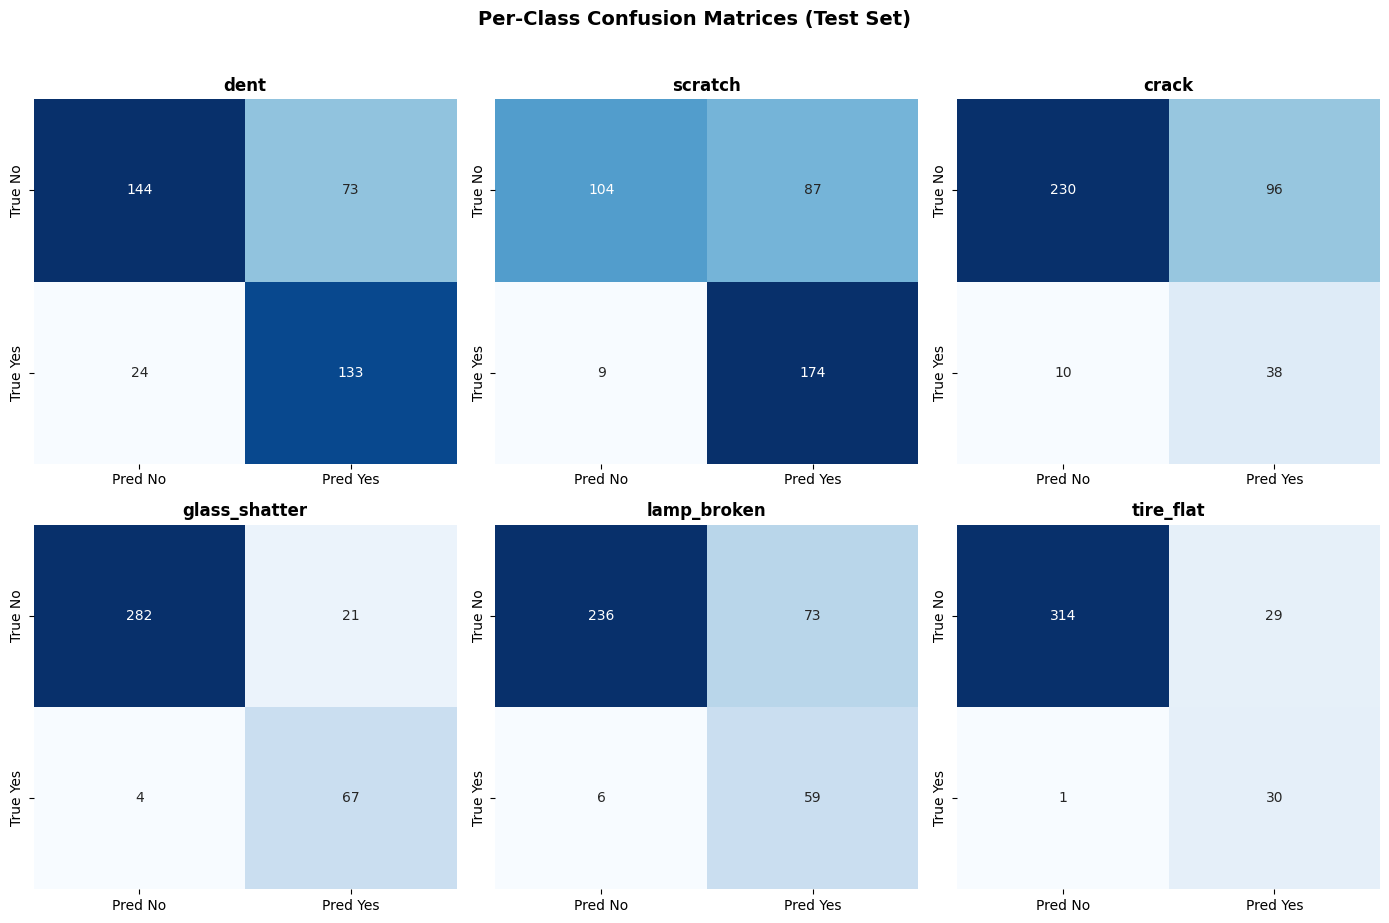

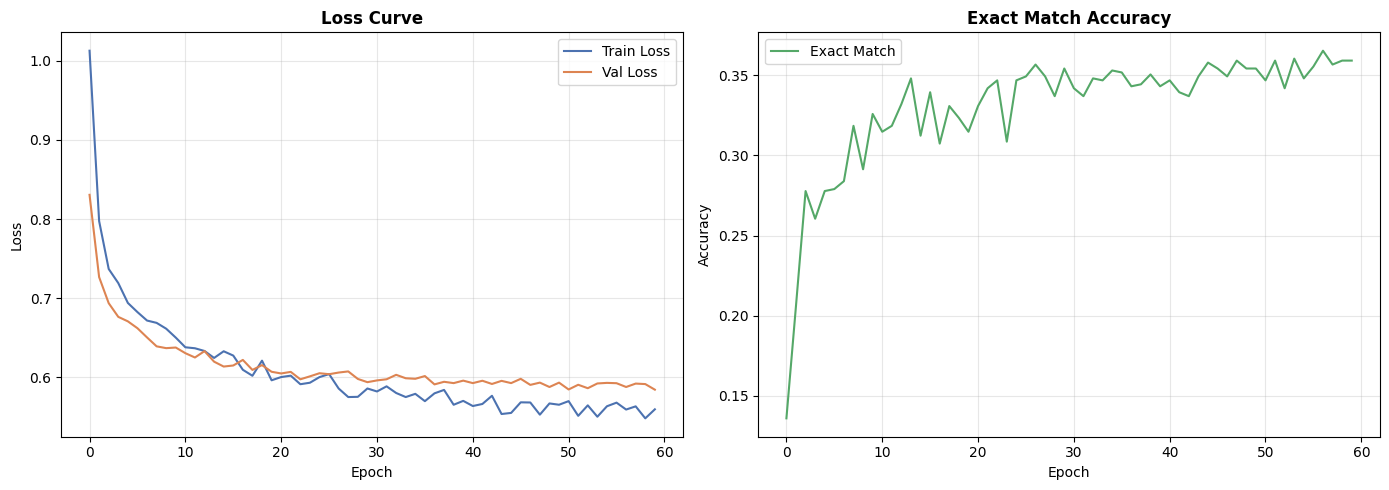

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (cls, ax) in enumerate(zip(CLASSES, axes)):
    cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['True No', 'True Yes'],
                cbar=False)
    ax.set_title(f'{cls}', fontsize=12, fontweight='bold')

plt.suptitle('Per-Class Confusion Matrices (Test Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#4C72B0')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#DD8452')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], label='Exact Match', color='#55A868')
axes[1].set_title('Exact Match Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


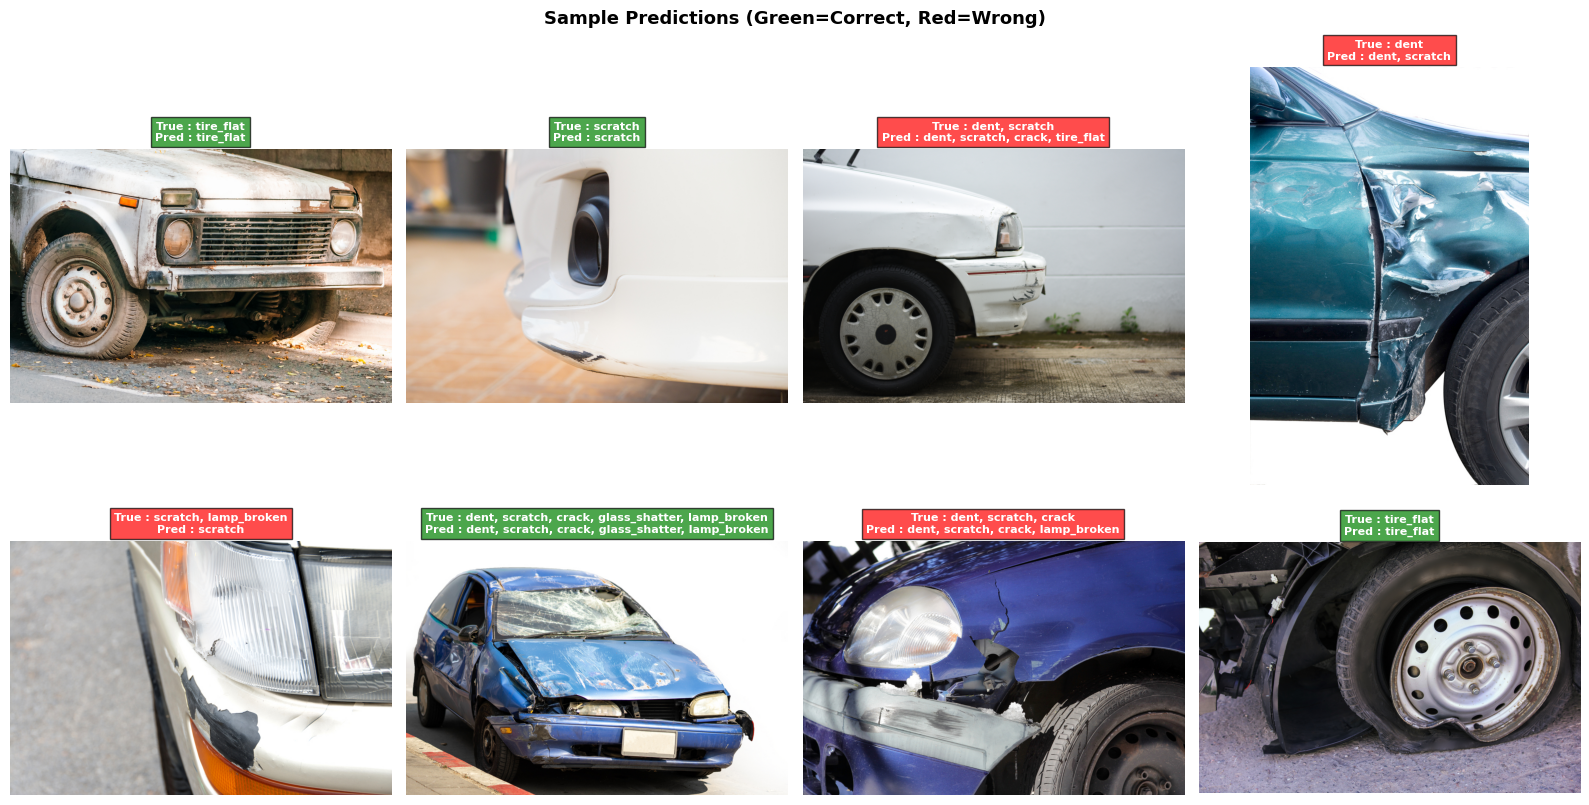


✅ Evaluation complete!


In [43]:


test_df = df[df['split_name'] == 'test'].reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i in range(8):
    row      = test_df.iloc[i]
    img_path = os.path.join(IMG_DIRS['test'], row['file_name'])
    img      = Image.open(img_path).convert('RGB')

    true_labels = [CLASSES[j] for j in range(6) if all_labels[i][j] == 1]
    pred_labels = [CLASSES[j] for j in range(6) if all_preds[i][j] == 1]
    correct     = set(true_labels) == set(pred_labels)

    axes[i].imshow(img)
    axes[i].set_title(
        f"True : {', '.join(true_labels)}\n"
        f"Pred : {', '.join(pred_labels) if pred_labels else 'none'}",
        fontsize=8, color='white', fontweight='bold',
        bbox=dict(facecolor='green' if correct else 'red', alpha=0.7, pad=3)
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Evaluation complete!")


## Improve threshold

In [44]:
best_thresholds = {}
new_preds = np.zeros_like(all_preds)
print(f"{'Class':<15} {'Best Threshold':>15} {'F1@0.5':>10} {'F1 @ best':>10} {'Gain':>8}")
for i, cls in enumerate(CLASSES):
    
    precision, recall, thresholds = precision_recall_curve(
        all_labels[:,i], all_probs[:,i])
    f1_scores = 2*(precision*recall)/(precision+recall+1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx<len(thresholds) else 0.5
    new_preds[:,i] = (all_probs[:,i] > best_threshold).astype(int)
    f1_new = f1_score(all_labels[:,i], new_preds[:,i], zero_division=0)
    f1_at_05= f1_score(all_labels[:,i], all_probs[:,i]>0.5, zero_division=0)
    gain = f1_new - f1_at_05
    best_thresholds[cls] = best_threshold.item()
    
    print(f"{cls:<15} {best_threshold:>15.4f} {f1_at_05:>10.4f} {f1_new:>10.4f} {gain:>8.4f}")
print("-"*55)
print("\nBest thresholds dict (save this!):")
print(best_thresholds)

Class            Best Threshold     F1@0.5  F1 @ best     Gain
dent                     0.5398     0.7328     0.7514   0.0187
scratch                  0.6065     0.7838     0.7913   0.0075
crack                    0.6603     0.4176     0.4655   0.0479
glass_shatter            0.7184     0.8428     0.9000   0.0572
lamp_broken              0.7475     0.5990     0.6569   0.0579
tire_flat                0.8488     0.6667     0.8214   0.1548
-------------------------------------------------------

Best thresholds dict (save this!):
{'dent': 0.5398045182228088, 'scratch': 0.6064741015434265, 'crack': 0.6602650284767151, 'glass_shatter': 0.718396008014679, 'lamp_broken': 0.7474693655967712, 'tire_flat': 0.8488282561302185}


In [45]:
with open('best_thresholds.json', 'w') as f:
    json.dump(best_thresholds,f, indent=4)
torch.save({
    'model_state_dict' : model.state_dict(),
    'thresholds'       : best_thresholds,
    'classes'          : CLASSES,
    'model_name'       : 'efficientnet_b3',
    'input_size'       : 224,
}, 'car_damage_classifier.pth')